In [82]:
import numpy as np
import pandas as pd
import random
from chemevo import evolution_V1 as evo
import itertools
import make_models_script
import glob

import matplotlib.pyplot as plt
from matplotlib import rcParams


params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

In [83]:
mg_h_big_bin_edges = np.arange(-0.7, 0.50, 0.20) 
mg_h_big_bin_centers = 0.5 * (mg_h_big_bin_edges[:-1] + mg_h_big_bin_edges[1:])

fe_mg_bin_edges = np.arange(-0.35, 0.15, 0.1)
fe_mg_centers = 0.5 * (fe_mg_bin_edges[:-1] + fe_mg_bin_edges[1:])


In [84]:
summary_df = pd.read_csv("data_lines_with_vals.csv")

def compute_mn_fe_model(row, fe_centers):
    return (row['slope_mn_fe'] * fe_centers) + row['intercept_mn_fe']

summary_df['mn_fe_model_vals'] = summary_df.apply(
    lambda r: compute_mn_fe_model(r, fe_mg_centers).tolist(), axis=1
)

In [85]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_mn_fe(param_to_plot, models_files_dir):
    
    # 1. Load the model files
    dfs = []
    plot_file_pattern = f"{models_files_dir}/{param_to_plot}_*"
    to_plot_files = glob.glob(plot_file_pattern)

    for path in to_plot_files:
        dfs.append(pd.read_csv(path))

    if not dfs:
        print("No data found.")
        return

    all_dfs = pd.concat(dfs, ignore_index=True)
    vmin = all_dfs[param_to_plot].min()
    vmax = all_dfs[param_to_plot].max()

    plt.figure(figsize=(20, 5))
    sc = None 

    # 2. Plotting loop
    for i in range(len(mg_h_big_bin_centers)):
        plt.subplot(1, 5, i + 1)
        
        for df in dfs:
            mask = np.isclose(df['mg_h_bin'], mg_h_big_bin_centers[i])
            subset = df[mask]
            
            if len(subset) == 0:
                continue

            val = subset[param_to_plot].iloc[0]
            
            # Standard scatter for all values
            sc = plt.scatter(subset['fe_mg'], subset['mn_fe'], alpha=0.3, 
                             label=f"{param_to_plot} = {val:.2f}", c=subset[param_to_plot], 
                             cmap='viridis', vmin=vmin, vmax=vmax)
                
        # Plot summary data
        mask_data = np.isclose(summary_df['mg_h_bin_center'], mg_h_big_bin_centers[i])
        data_subset = summary_df[mask_data]

        if len(data_subset) > 0:
            plt.plot(fe_mg_centers, data_subset['mn_fe_model_vals'].iloc[0], color='black', marker='o', zorder=12)

        if i == 0:
            plt.ylabel('[Mn/Fe]')
            plt.legend(bbox_to_anchor=[-0.5, 1])

        plt.grid(True, alpha=0.3)
        plt.xlim(-0.60, 0.25)
        plt.ylim(-0.8, 0.40)
        plt.xlabel('[Fe/Mg]')

    if sc is not None:
        cbar = plt.colorbar(sc, ax=plt.gcf().axes)
        cbar.set_label(param_to_plot)
        
    plt.show()

In [86]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_mn_fe(param_to_plot, models_files_dir):
    
    # 1. Load the model files and assign colors based on filename
    dfs_with_colors = []
    plot_file_pattern = f"{models_files_dir}/{param_to_plot}_*"
    to_plot_files = glob.glob(plot_file_pattern)

    # Dictionary to store the parameter values for each iteration
    iter_vals = {'iter0': [], 'iter1': []}

    for path in to_plot_files:
        df = pd.read_csv(path)
        
        # Extract the parameter value for this specific file
        val = df[param_to_plot].iloc[0]
        
        # Determine color based on filename and store the value
        if 'iter0' in path:
            color = 'blue'
            iter_vals['iter0'].append(val)
        elif 'iter1' in path:
            color = 'red'
            iter_vals['iter1'].append(val)
        else:
            color = 'gray' # Fallback for any unexpected files
            
        dfs_with_colors.append((df, color))

    if not dfs_with_colors:
        print("No data found.")
        return

    # Calculate and print the medians for each iteration
    if iter_vals['iter0']:
        median_iter0 = np.median(iter_vals['iter0'])
        print(f"Median {param_to_plot} for iter0: {median_iter0:.3f}")
        
    if iter_vals['iter1']:
        median_iter1 = np.median(iter_vals['iter1'])
        print(f"Median {param_to_plot} for iter1: {median_iter1:.3f}")

    plt.figure(figsize=(20, 5))

    # 2. Plotting loop
    for i in range(len(mg_h_big_bin_centers)):
        plt.subplot(1, 5, i + 1)
        
        for df, color in dfs_with_colors:
            mask = np.isclose(df['mg_h_bin'], mg_h_big_bin_centers[i])
            subset = df[mask]
            
            if len(subset) == 0:
                continue

            val = subset[param_to_plot].iloc[0]
            
            # Scatter for all values using the assigned color
            plt.scatter(subset['fe_mg'], subset['mn_fe'], alpha=0.3, 
                        color=color, label=f"{param_to_plot} = {val:.2f}")
                
        # Plot summary data
        mask_data = np.isclose(summary_df['mg_h_bin_center'], mg_h_big_bin_centers[i])
        data_subset = summary_df[mask_data]

        if len(data_subset) > 0:
            plt.plot(fe_mg_centers, data_subset['mn_fe_model_vals'].iloc[0], color='black', marker='o', zorder=12)

        if i == 0:
            plt.ylabel('[Mn/Fe]')
            plt.legend(bbox_to_anchor=[-0.5, 1])

        plt.grid(True, alpha=0.3)
        plt.xlim(-0.60, 0.25)
        plt.ylim(-0.8, 0.40)
        plt.xlabel('[Fe/Mg]')
        
    plt.show()

# Models 3

 --alpha_cc 0.50 --alpha_Ia 0.80 --g_cc 0.40 --g_ratio 1.90 --save_dir "unity_models_3"

Median alpha_cc for iter0: 0.500


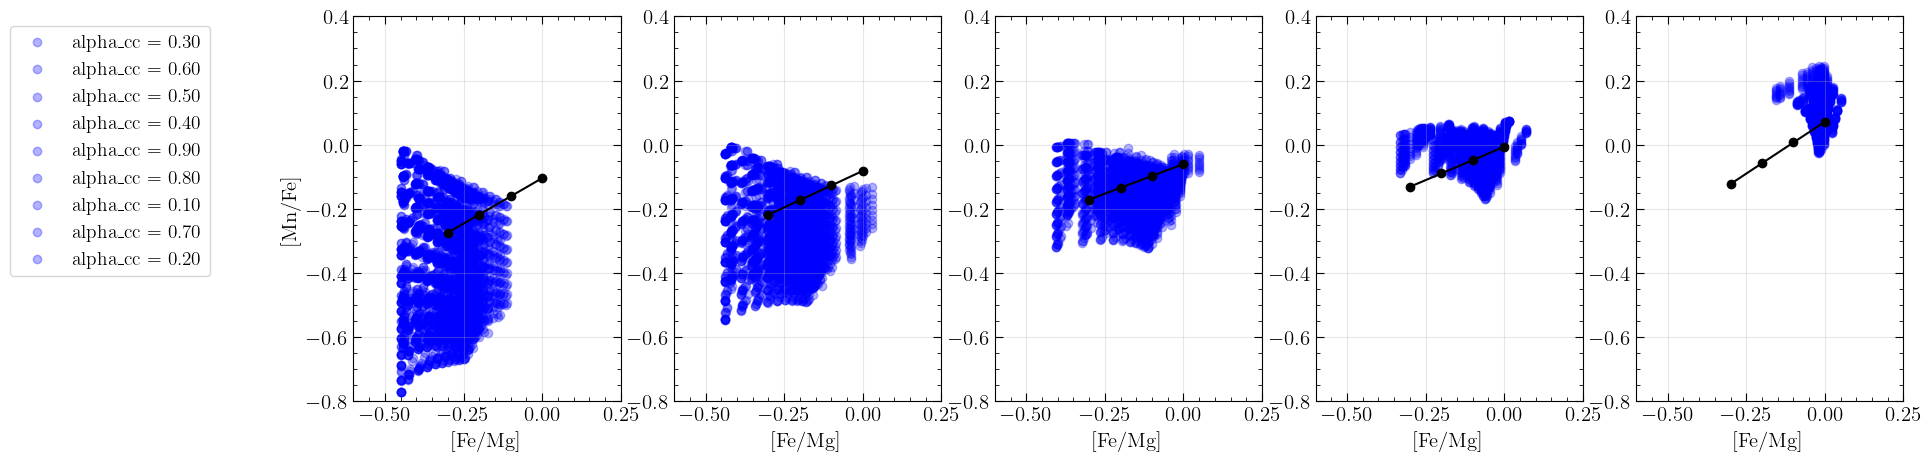

In [87]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="unity_models_3")

Median alpha_Ia for iter0: 0.800


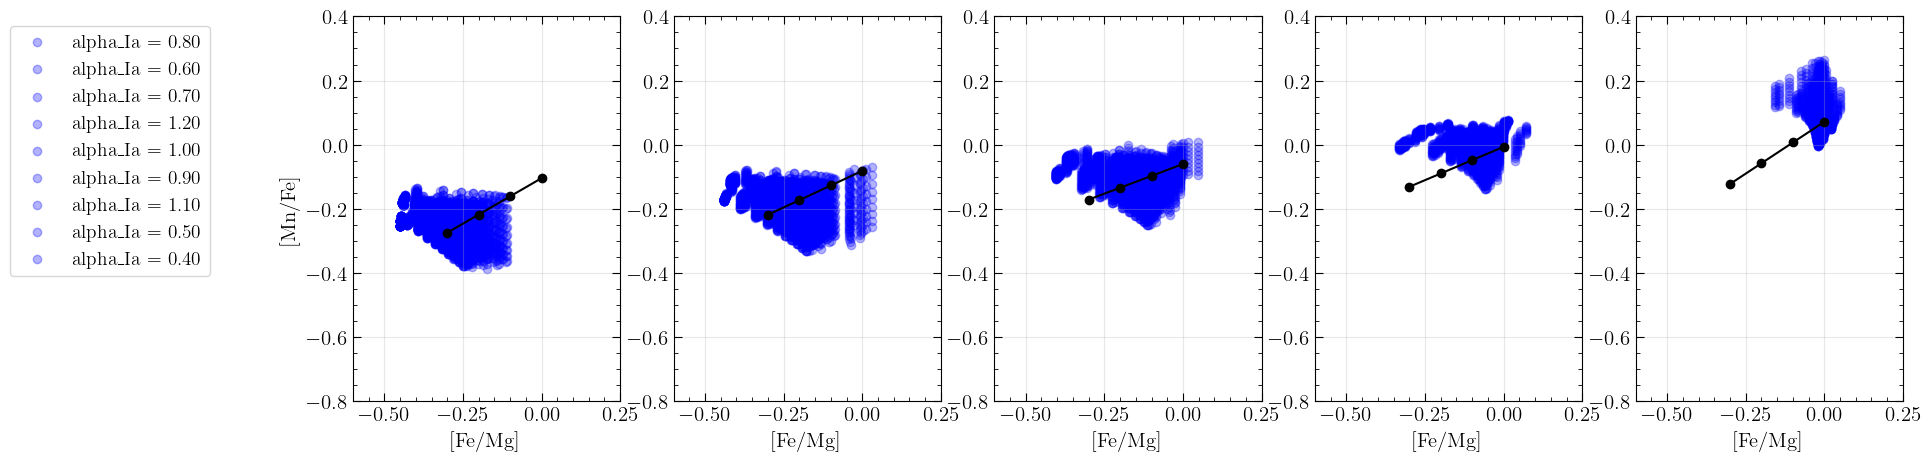

In [88]:
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="unity_models_3")

Median g_cc for iter0: 0.400


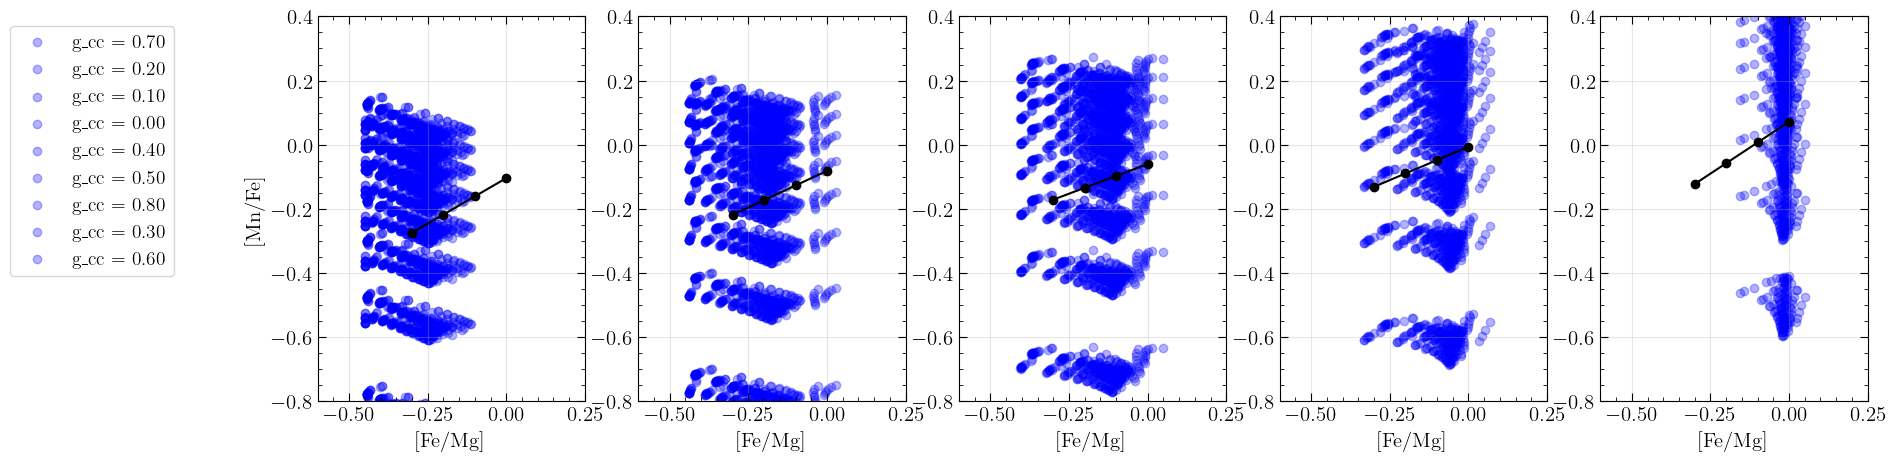

In [89]:
plot_mn_fe(param_to_plot="g_cc", models_files_dir="unity_models_3")

Median g_ratio for iter0: 1.650


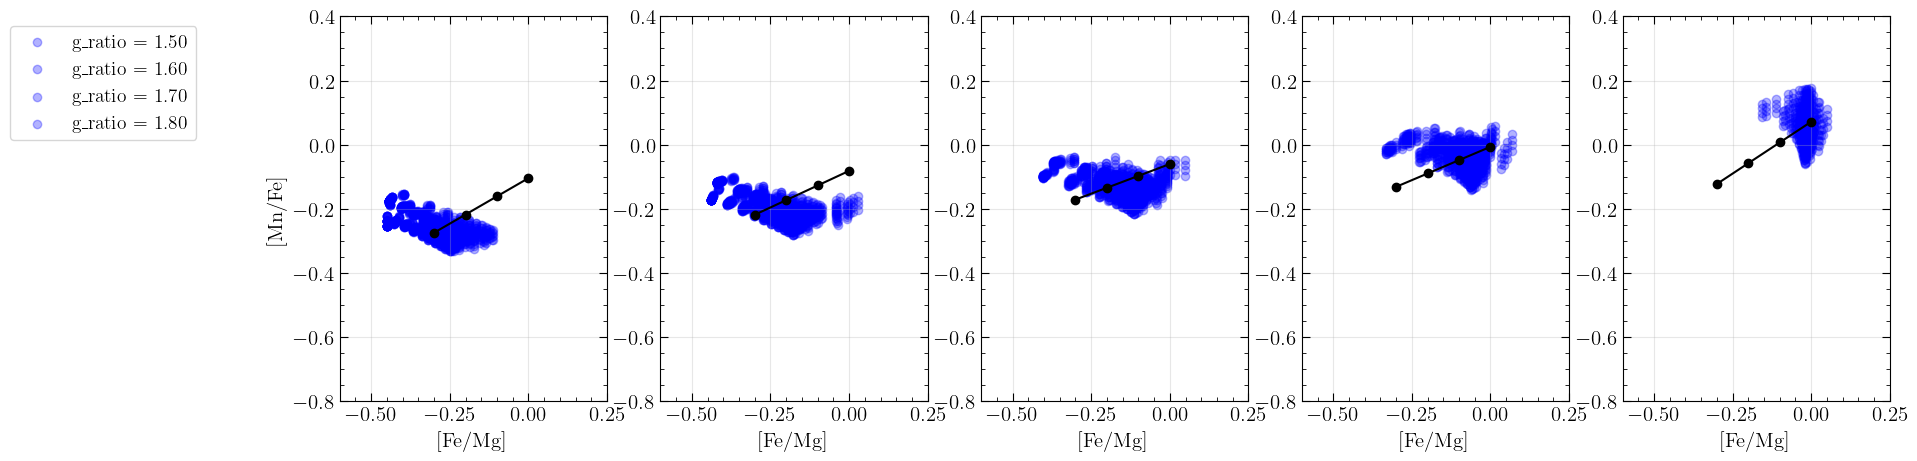

In [90]:
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="unity_models_3")

# Models 4

--alpha_cc 0.50 --alpha_Ia 0.40 --g_cc 0.20 --g_ratio 1.90 --save_dir "unity_models_4"

Median alpha_cc for iter0: 0.200
Median alpha_cc for iter1: 0.400


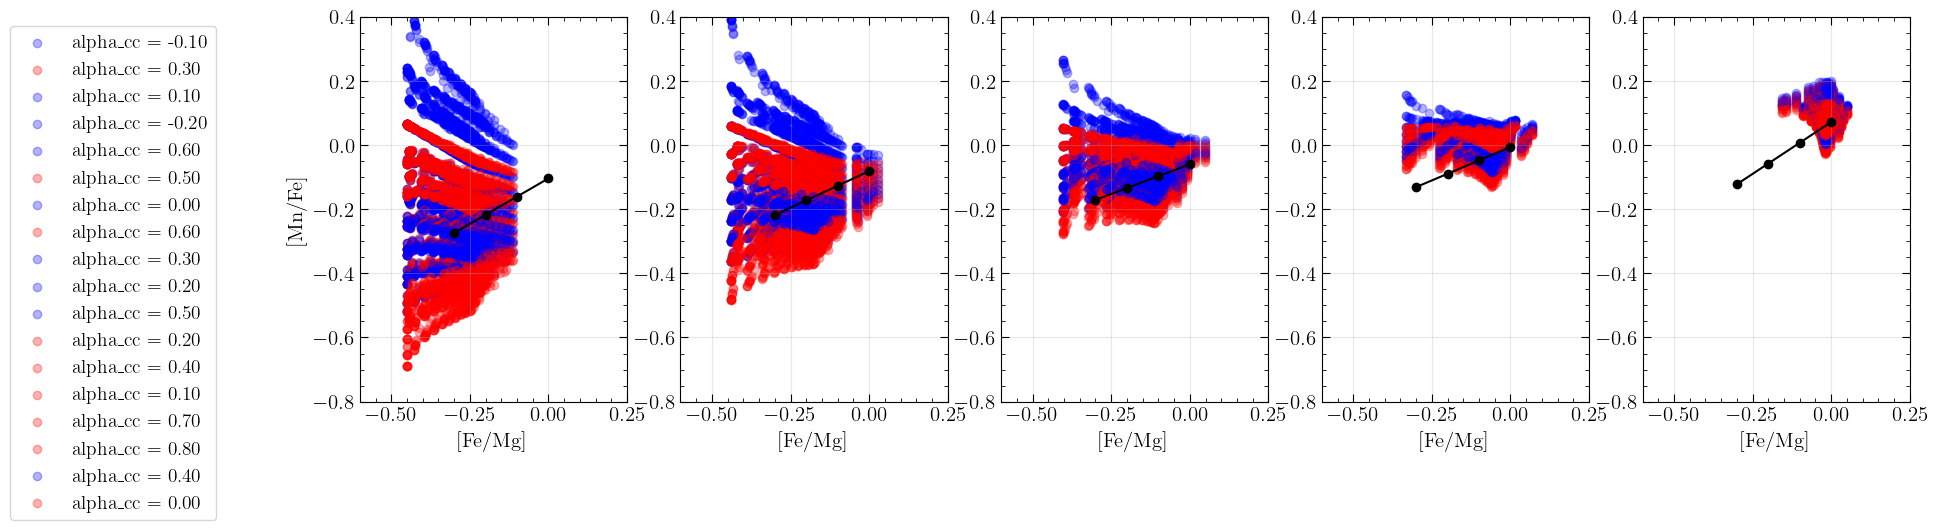

In [91]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="unity_models_4")

Median alpha_Ia for iter0: 0.600
Median alpha_Ia for iter1: 0.500


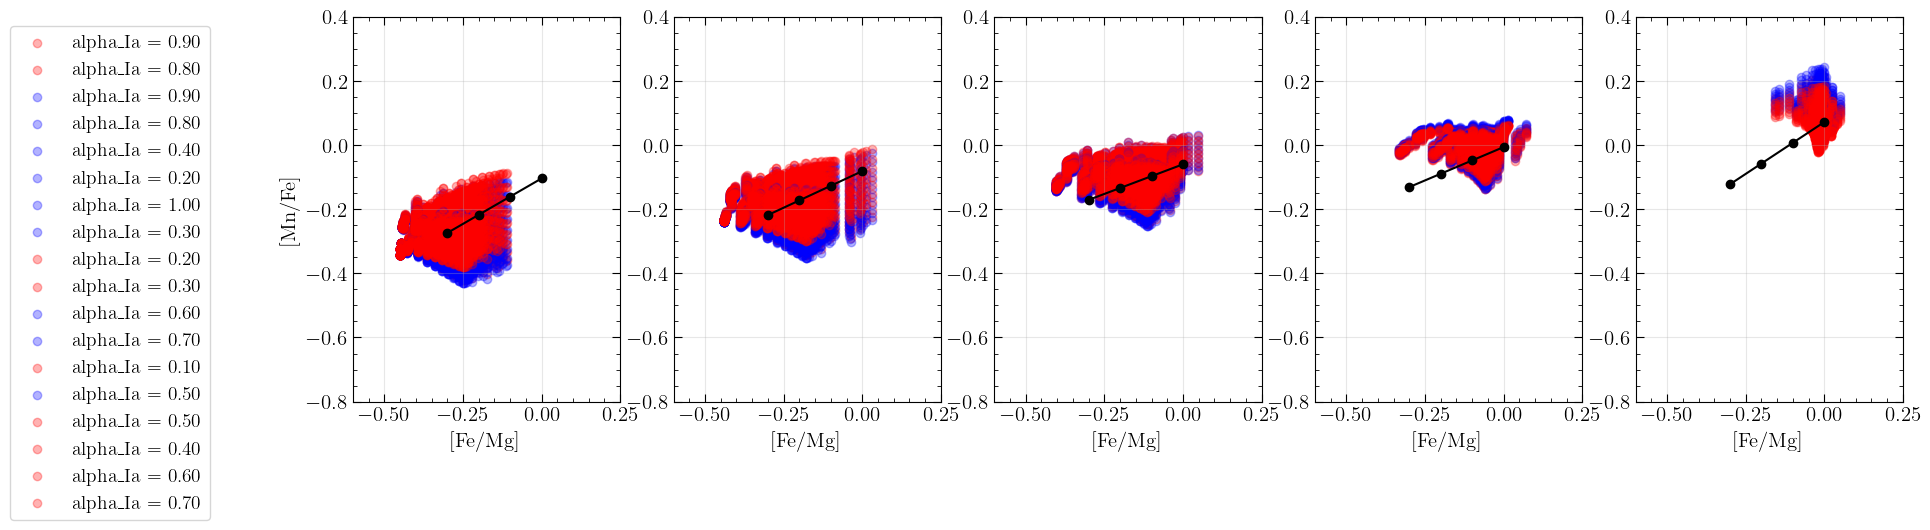

In [92]:
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="unity_models_4")

Median g_cc for iter0: 0.400
Median g_cc for iter1: 0.400


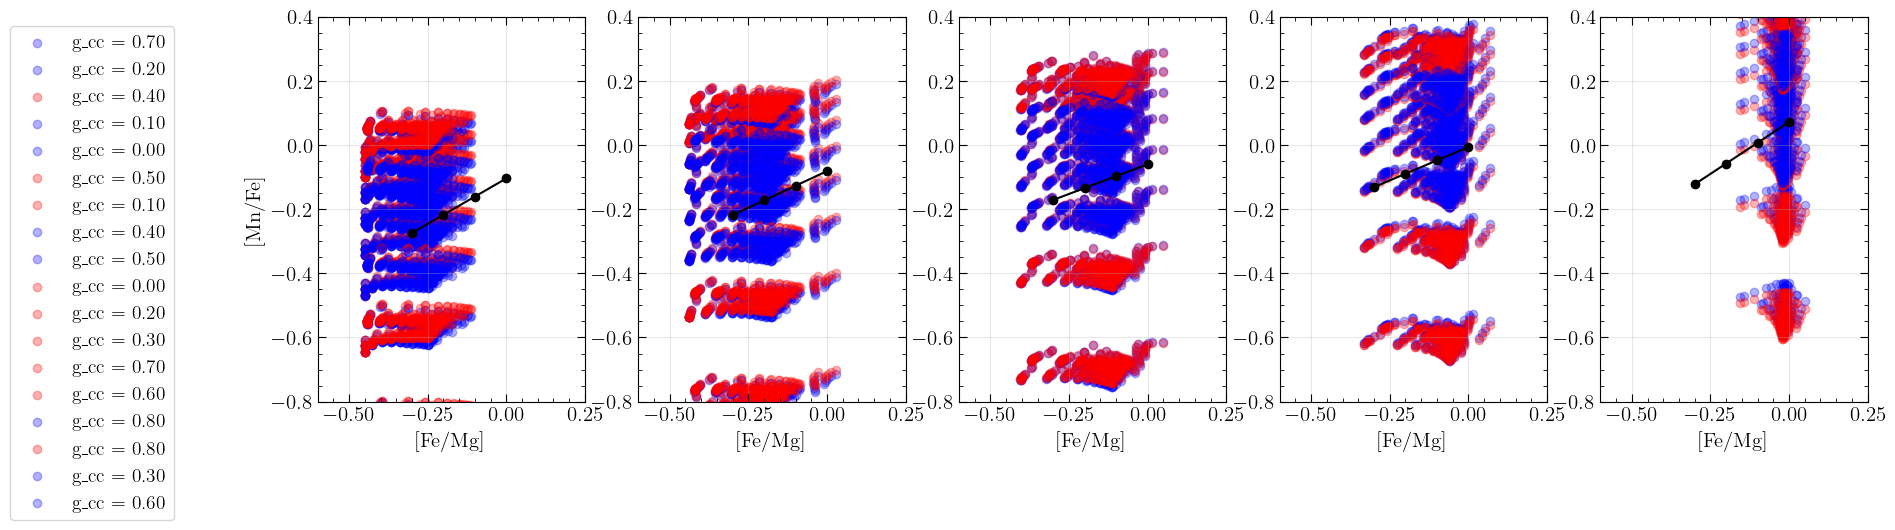

In [93]:
plot_mn_fe(param_to_plot="g_cc", models_files_dir="unity_models_4")

Median g_ratio for iter0: 1.900
Median g_ratio for iter1: 1.450


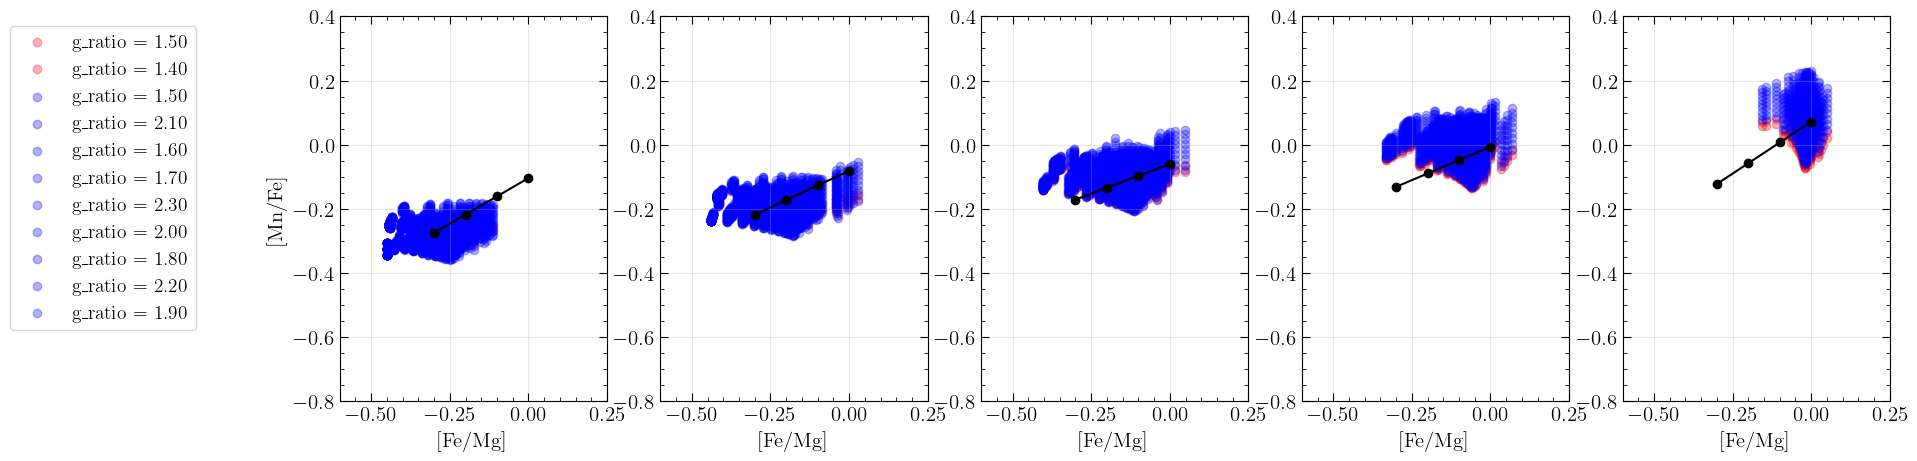

In [94]:
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="unity_models_4")

# Models 5

 --alpha_cc 0.50 --alpha_Ia 0.40 --g_cc 0.80 --g_ratio 1.90 --save_dir "unity_models_5"

Median alpha_cc for iter0: 0.500
Median alpha_cc for iter1: 0.800


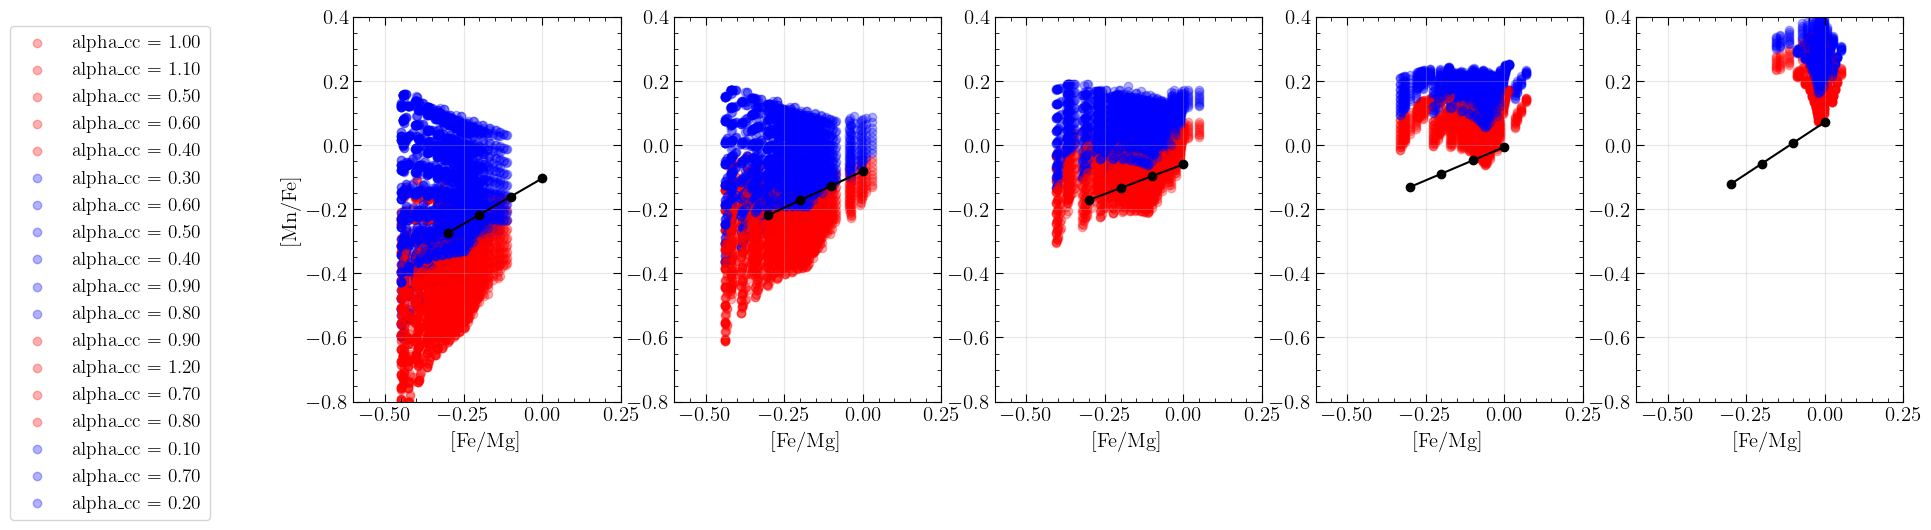

In [95]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="unity_models_5")

Median alpha_Ia for iter0: 0.600
Median alpha_Ia for iter1: 0.600


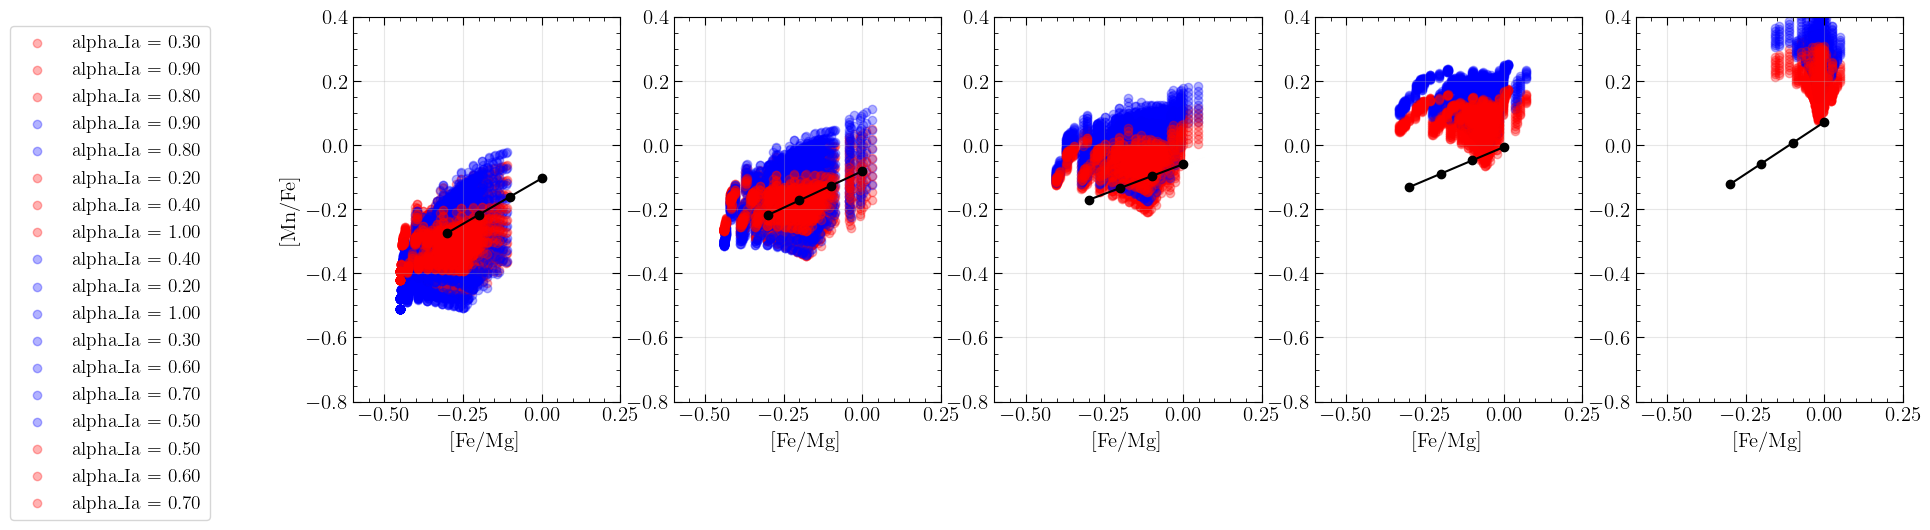

In [96]:
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="unity_models_5")

Median g_cc for iter0: 0.600
Median g_cc for iter1: 0.500


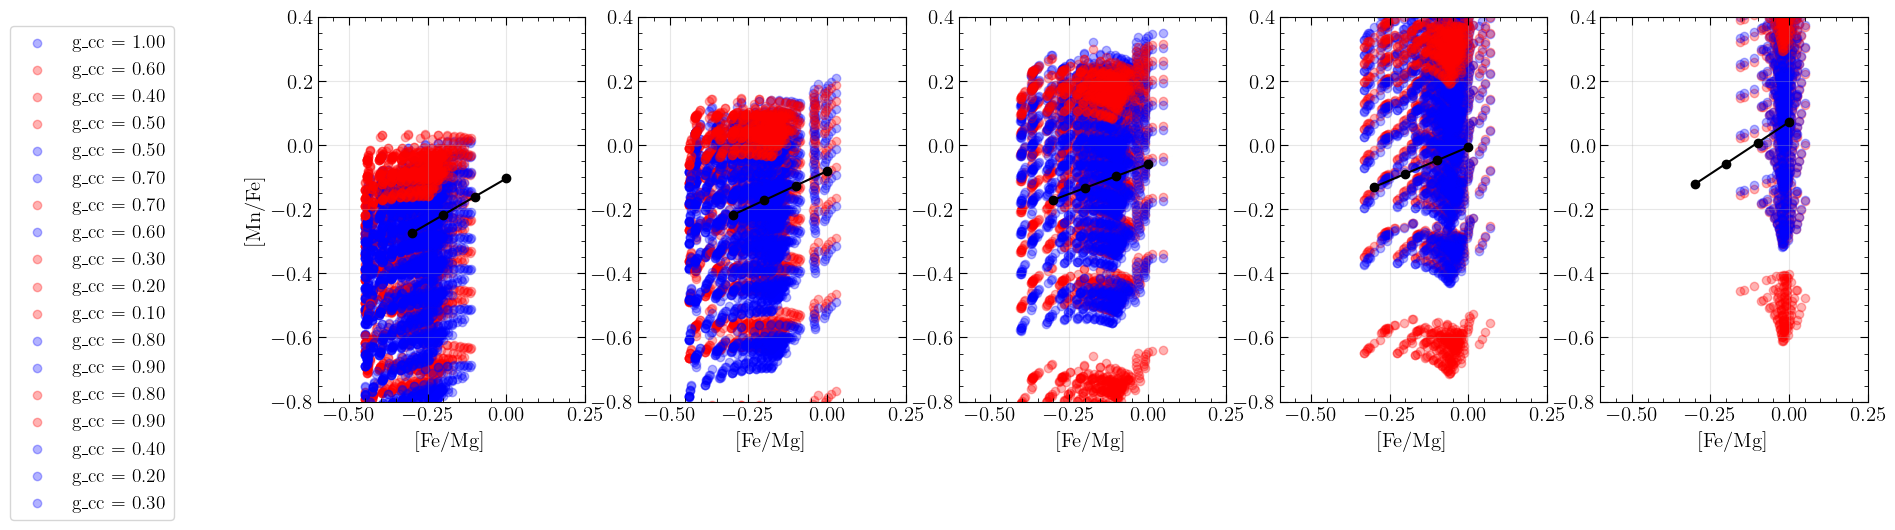

In [97]:
plot_mn_fe(param_to_plot="g_cc", models_files_dir="unity_models_5")

Median g_ratio for iter0: 1.900
Median g_ratio for iter1: 1.550


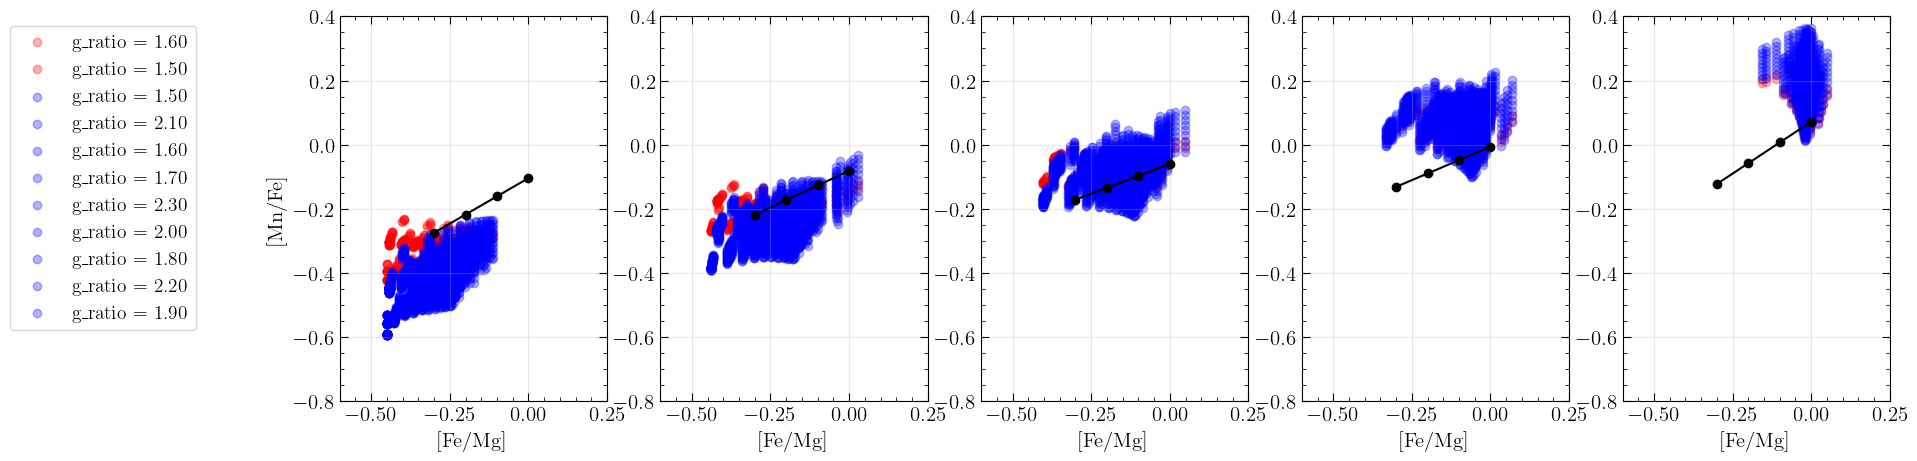

In [98]:
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="unity_models_5")

# Models 6

 --alpha_cc 0.50 --alpha_Ia 0.40 --g_cc 0.40 --g_ratio 1.60 --save_dir "unity_models_6"

Median alpha_cc for iter0: 0.500
Median alpha_cc for iter1: 0.300


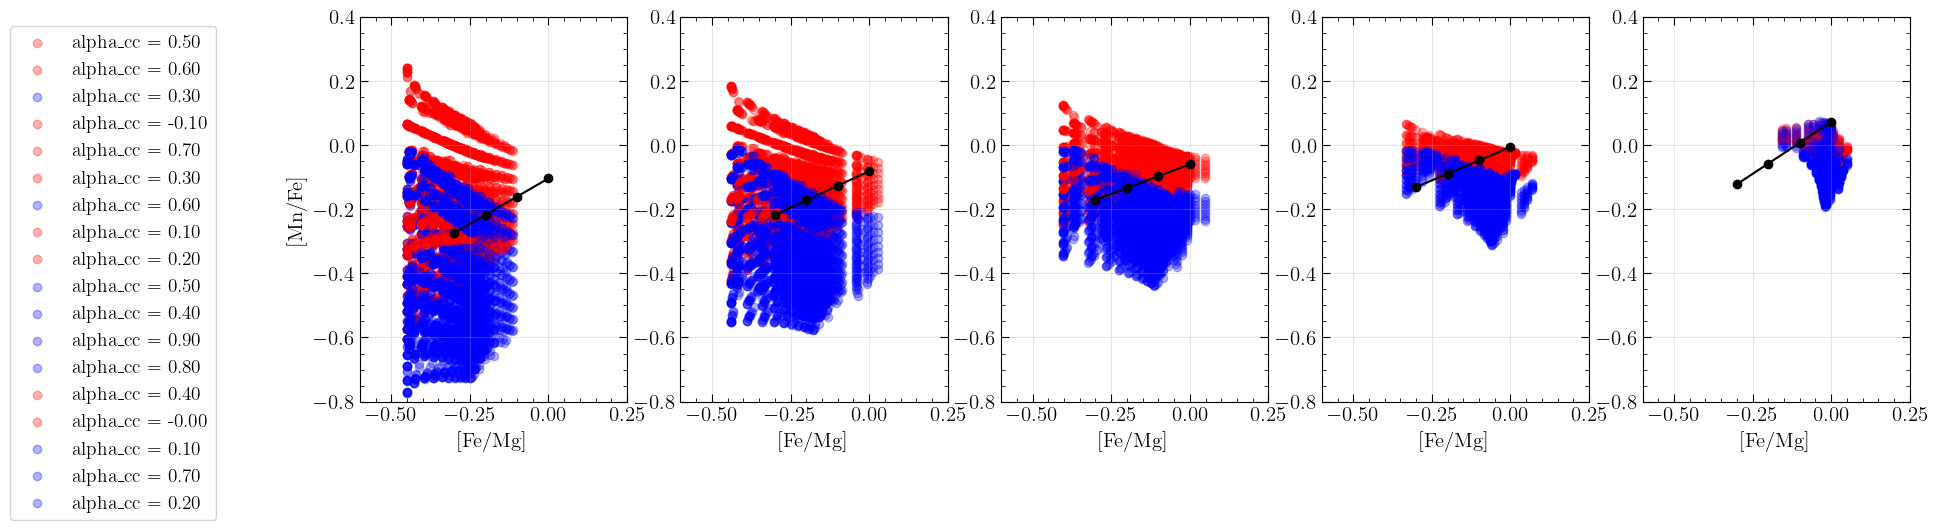

In [99]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="unity_models_6")

Median alpha_Ia for iter0: 0.600
Median alpha_Ia for iter1: 0.200


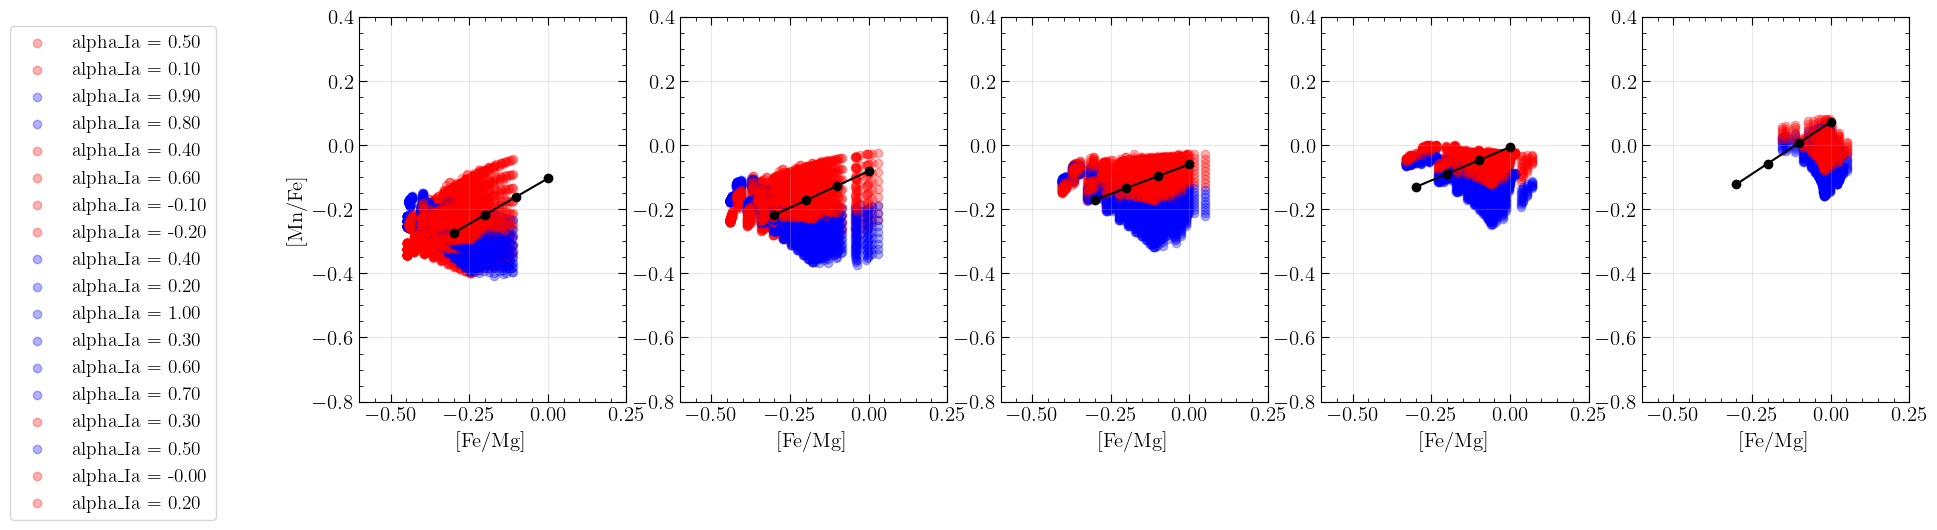

In [100]:
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="unity_models_6")

Median g_cc for iter0: 0.400
Median g_cc for iter1: 0.400


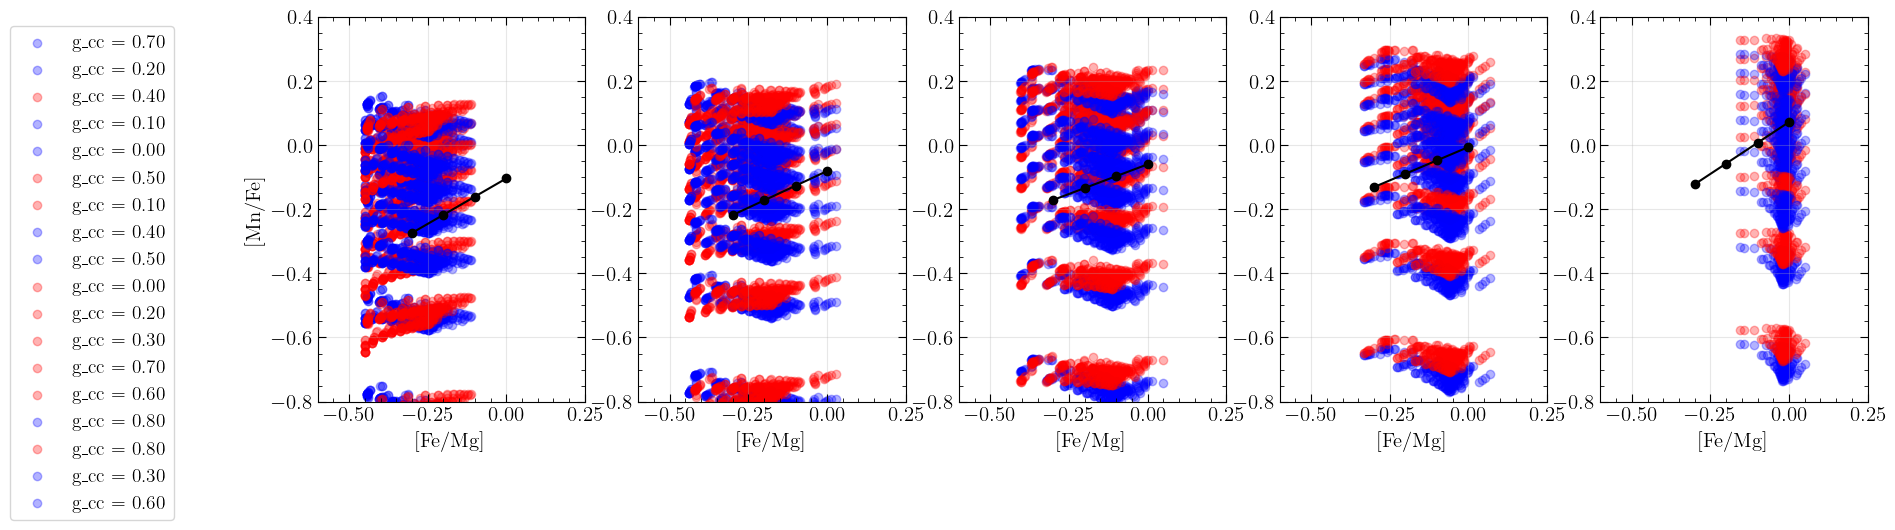

In [101]:
plot_mn_fe(param_to_plot="g_cc", models_files_dir="unity_models_6")

Median g_ratio for iter0: 1.000
Median g_ratio for iter1: 1.000


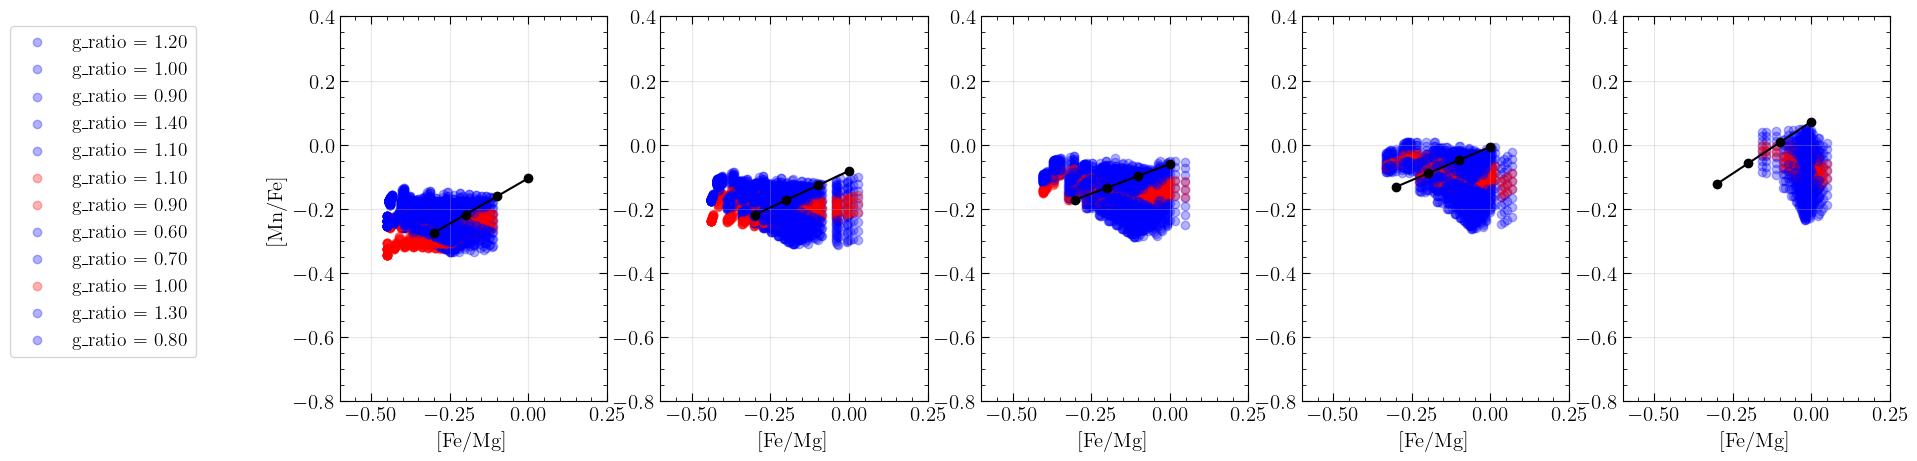

In [102]:
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="unity_models_6")

# Models 7

--alpha_cc 0.50 --alpha_Ia 0.40 --g_cc 0.40 --g_ratio 2.2 --save_dir "unity_models_7"

Median alpha_cc for iter0: 0.700
Median alpha_cc for iter1: 0.900


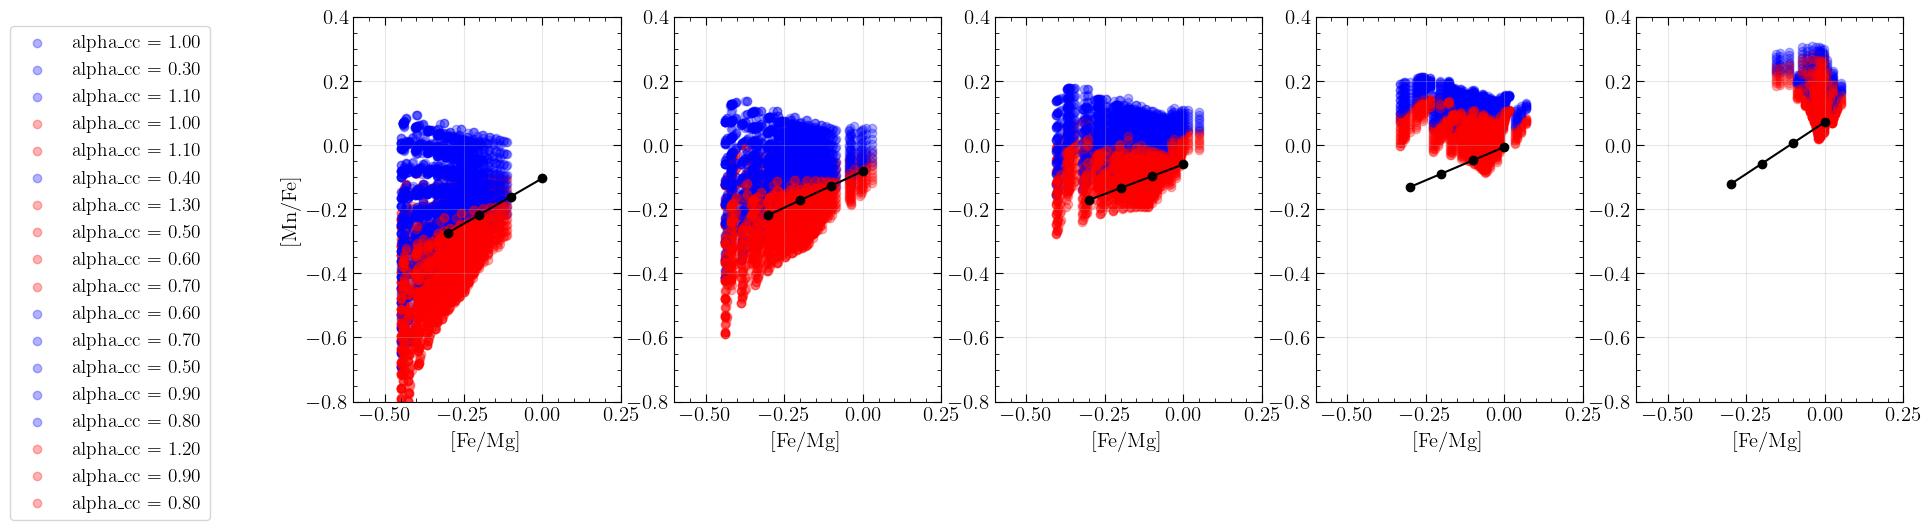

Median alpha_Ia for iter0: 0.200
Median alpha_Ia for iter1: 0.200


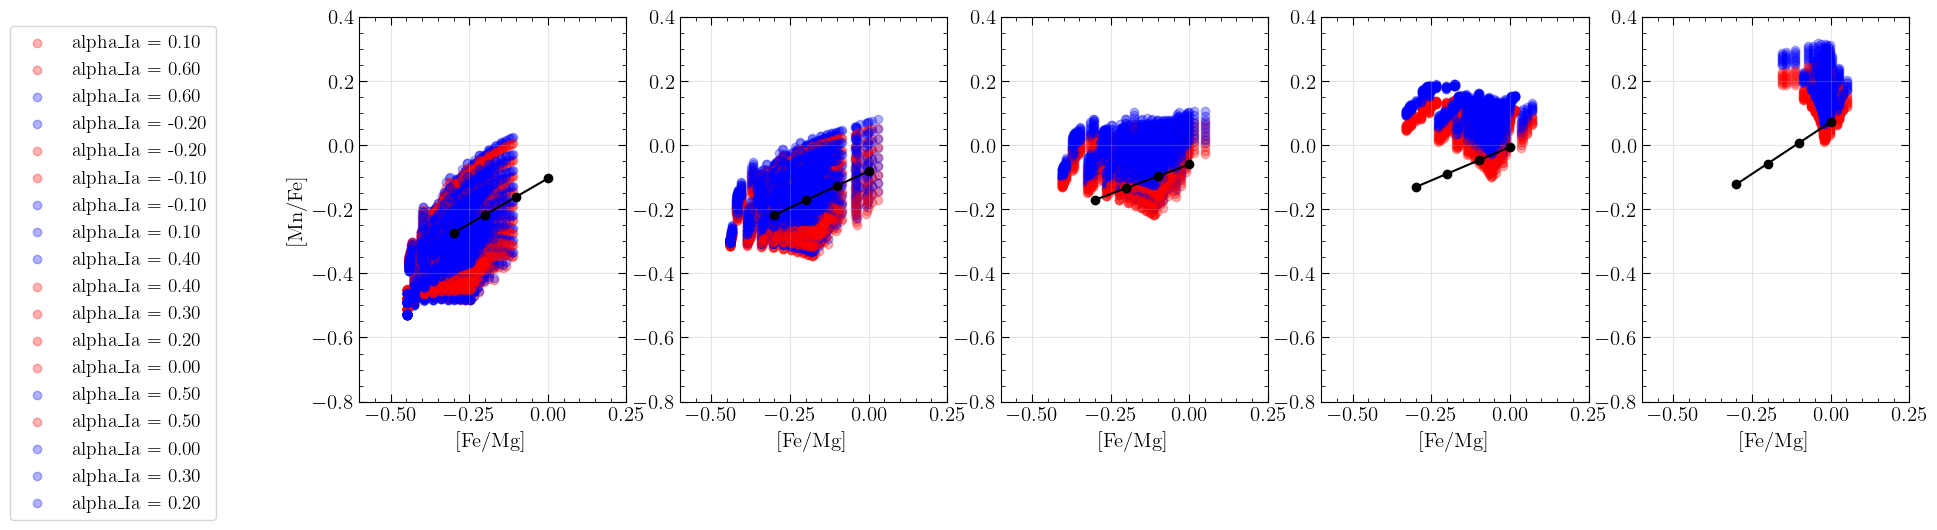

Median g_cc for iter0: 0.700
Median g_cc for iter1: 0.600


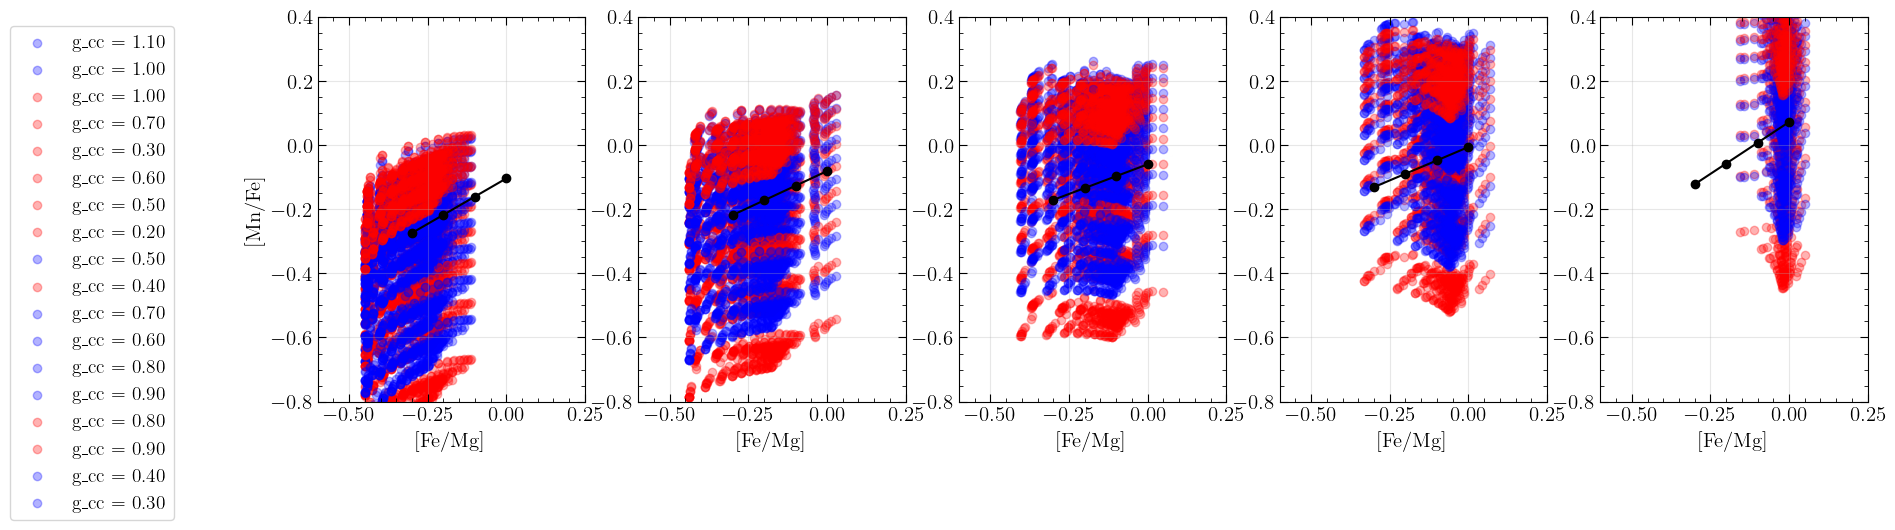

Median g_ratio for iter0: 1.000
Median g_ratio for iter1: 0.800


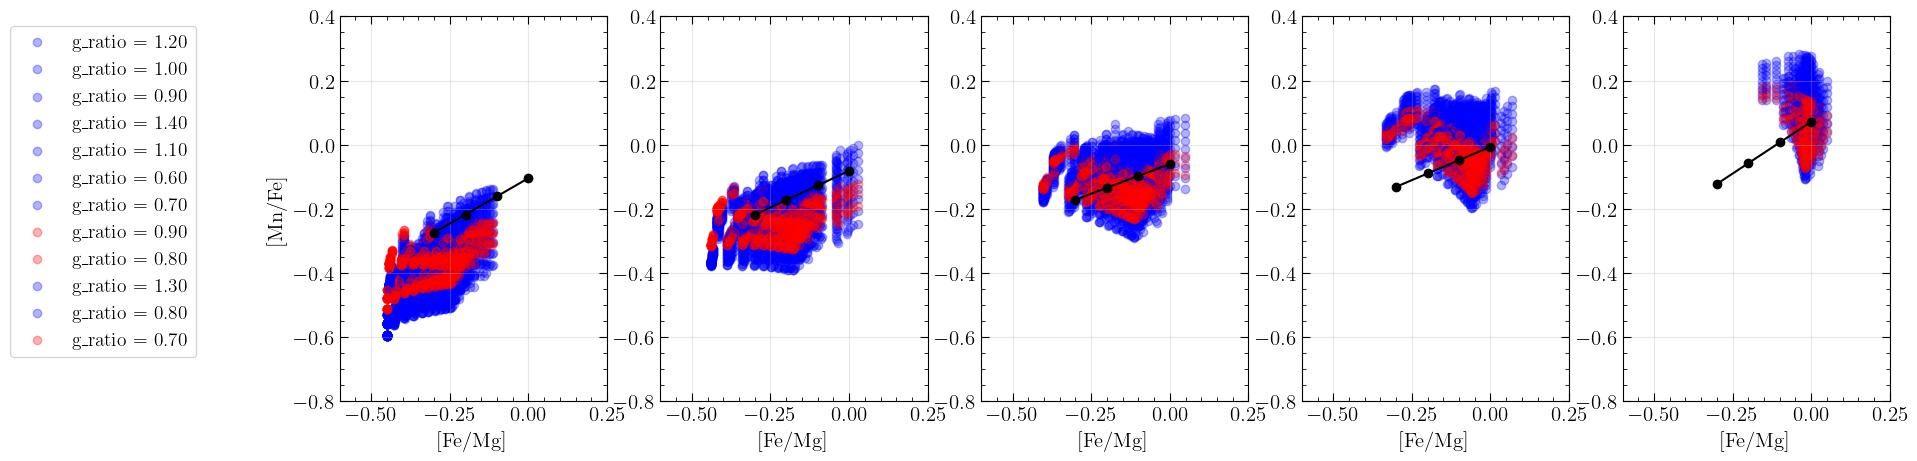

In [103]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="unity_models_7")
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="unity_models_7")
plot_mn_fe(param_to_plot="g_cc", models_files_dir="unity_models_7")
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="unity_models_7")

# Models 8

--alpha_cc 0.20 --alpha_Ia 0.80 --g_cc 0.20 --g_ratio 1.60 --save_dir "unity_models_8"

In [104]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="unity_models_8")
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="unity_models_8")
plot_mn_fe(param_to_plot="g_cc", models_files_dir="unity_models_8")
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="unity_models_8")

No data found.
No data found.
No data found.
No data found.


# Models 9
--alpha_cc 0.80 --alpha_Ia 0.30 --g_cc 0.60 --g_ratio 1.50 --save_dir "unity_models_9"

In [105]:
plot_mn_fe(param_to_plot="alpha_cc", models_files_dir="unity_models_9")
plot_mn_fe(param_to_plot="alpha_Ia", models_files_dir="unity_models_9")
plot_mn_fe(param_to_plot="g_cc", models_files_dir="unity_models_9")
plot_mn_fe(param_to_plot="g_ratio", models_files_dir="unity_models_9")

No data found.
No data found.
No data found.
No data found.


In [106]:
(2.898 * 10**-3)/(5800) / 10**(-9)

499.65517241379314